In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
df_quality = pd.read_csv("latent_learning/legal_ffma_quality_results.csv")
print(len(df_quality))
df_quality = df_quality[df_quality['quality']!=0.0]
print(len(df_quality))
df_quality = df_quality.sort_values(by="query_plan")

535
412


In [17]:
print(df_quality["query_plan"].map(type).value_counts())
df_quality['query_plan'].value_counts()

query_plan
<class 'str'>    412
Name: count, dtype: int64


query_plan
(('Anti-Assignment', 'Cap on Liability', 'Expiration Date'), 'FFM')    54
(('Anti-Assignment', 'Cap on Liability', 'Governing Law'), 'FFM')      54
(('Anti-Assignment', 'License Grant', 'Expiration Date'), 'FFM')       54
(('Anti-Assignment', 'License Grant', 'Governing Law'), 'FFM')         54
(('Anti-Assignment', 'Cap on Liability', 'Governing Law'), 'FFA')      52
(('Anti-Assignment', 'License Grant', 'Governing Law'), 'FFA')         52
(('Anti-Assignment', 'Audit Rights', 'Governing Law'), 'FFM')          39
(('Anti-Assignment', 'Audit Rights', 'Expiration Date'), 'FFM')        27
(('Anti-Assignment', 'Audit Rights', 'Governing Law'), 'FFA')          26
Name: count, dtype: int64

In [18]:
test_query = [
    (('Anti-Assignment', 'Audit Rights', 'Governing Law'), 'FFM'),
    (('Anti-Assignment', 'Audit Rights', 'Expiration Date'), 'FFM'),
    (('Anti-Assignment', 'Audit Rights', 'Governing Law'), 'FFA'),
]

test_query_set = set(str(q) for q in test_query)

df_test = df_quality[df_quality["query_plan"].isin(test_query_set)]
df_train = df_quality[~df_quality["query_plan"].isin(test_query_set)]
df_test.to_csv("latent_learning/data/100_CUAD/100_CUAD_test.csv", index=False)
df_train.to_csv("latent_learning/data/100_CUAD/100_CUAD_train.csv", index=False)

Top consistently high performers:
query_plan                                      mean_quality  std_quality
physical_plan                                                            
('GPT_4o_MINI', 'GPT_5_MINI', 'GPT_4_1_MINI')       0.813595     0.150759
('GPT_4o_MINI', 'GPT_4o_MINI', 'GPT_4_1_MINI')      0.796838     0.133307
('GPT_4_1', 'GPT_4_1', 'GPT_5_MINI')                0.780233     0.193763
('GPT_5_MINI', 'GPT_5_MINI', 'GPT_4_1_MINI')        0.750139     0.239281
('GPT_4_1', 'GPT_5_MINI', 'GPT_4_1_MINI')           0.701175     0.274224
('GPT_5_MINI', 'GPT_4_1', 'GPT_4_1_MINI')           0.698403     0.114557
('GPT_5_MINI', 'GPT_5_MINI', 'GPT_5_MINI')          0.688522     0.104259
('GPT_4_1', 'GPT_4_1', 'GPT_4_1')                   0.684008     0.184560
('GPT_5_MINI', 'GPT_4_1', 'GPT_5_MINI')             0.681026     0.072850
('GPT_5_MINI', 'GPT_4o_MINI', 'GPT_4_1_MINI')       0.656442     0.108134

Top consistently low performers:
query_plan                                  

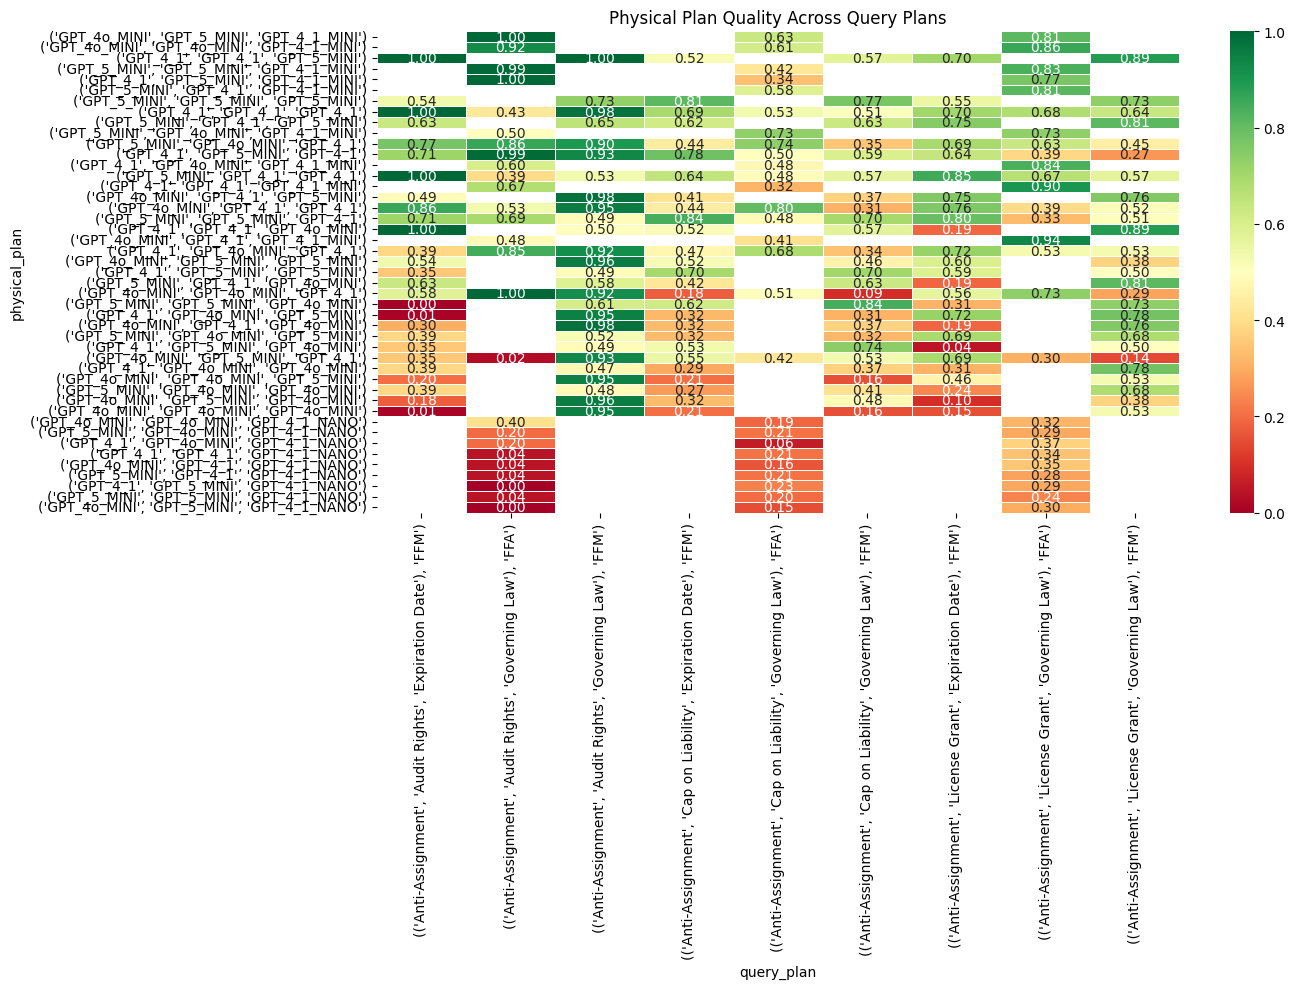

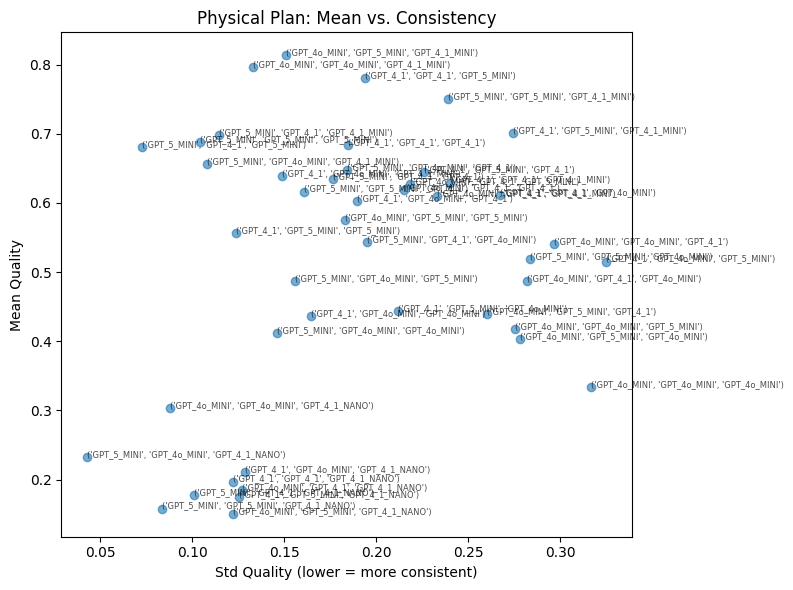

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_train = pd.read_csv("latent_learning/data/100_CUAD/100_CUAD_train.csv")
df_train["quality_norm"] = df_train.groupby("query_plan")["quality"].transform(
    lambda x: (x - x.min()) / (x.max() - x.min())
)
df_test = pd.read_csv("latent_learning/data/100_CUAD/100_CUAD_test.csv")
df_test["quality_norm"] = df_test.groupby("query_plan")["quality"].transform(
    lambda x: (x - x.min()) / (x.max() - x.min())
)

df = pd.concat([df_train, df_test])

# Pivot: physical_plan x query_plan -> mean quality
pivot = df.groupby(["physical_plan", "query_plan"])["quality_norm"].mean().unstack("query_plan")

# Row-wise mean and std across all query plans
pivot["mean_quality"] = pivot.mean(axis=1)
pivot["std_quality"] = pivot.std(axis=1)
pivot = pivot.sort_values("mean_quality", ascending=False)

print("Top consistently high performers:")
print(pivot[["mean_quality", "std_quality"]].head(10))
print("\nTop consistently low performers:")
print(pivot[["mean_quality", "std_quality"]].tail(10))

# Average rank: lower rank = better
rank_pivot = df_train.groupby(["physical_plan", "query_plan"])["quality"].mean().unstack("query_plan")
avg_rank = rank_pivot.rank(ascending=False).mean(axis=1).sort_values()
print("\nBest average rank (most consistently good):")
print(avg_rank.head(10))

# Heatmap of quality (drop the stat columns first)
heatmap_data = pivot.drop(columns=["mean_quality", "std_quality"])
plt.figure(figsize=(14, 10))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="RdYlGn", linewidths=0.5)
plt.title("Physical Plan Quality Across Query Plans")
plt.tight_layout()
plt.show()

# Scatter: mean vs std — top-left = consistently good
plt.figure(figsize=(8, 6))
plt.scatter(pivot["std_quality"], pivot["mean_quality"], alpha=0.6)
for pp, row in pivot.iterrows():
    plt.annotate(pp, (row["std_quality"], row["mean_quality"]), fontsize=6, alpha=0.7)
plt.xlabel("Std Quality (lower = more consistent)")
plt.ylabel("Mean Quality")
plt.title("Physical Plan: Mean vs. Consistency")
plt.tight_layout()
plt.show()
